<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 10.  Classification Algorithms
### Statistics & Quantitative Methods for Data Science

Regression (Week 4) predicts a continuous number. **Classification** predicts a category. This class introduces three foundational classifiers — each resting on a different statistical idea — and compares them head-to-head.

**This notebook:**
1. The classification problem, and a decision boundary
2. Logistic regression — probability via the sigmoid
3. K-Nearest Neighbors — classification by similarity
4. Decision Trees — classification via information gain
5. Comparing all three
6. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)

df = titanic.dropna(subset=['age', 'fare', 'pclass', 'sex', 'survived']).copy()
df['sex_code'] = df['sex'].map({'male':0, 'female':1})
features = ['pclass', 'sex_code', 'age', 'fare']
X, y = df[features], df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 535, Test: 179


---
# 1. The classification problem & decision boundaries

Every classifier we meet today does the same fundamental thing: it carves up **feature space** into regions, one per class. A new data point gets the label of whatever region it lands in. The *shape* of that boundary is what differs — a straight line, a curved surface, or a set of rectangular splits.

To visualize this cleanly, we'll use just **2 features** (`age`, `fare`) throughout this notebook.

In [ ]:
X2 = df[['age', 'fare']].to_numpy()
y2 = df['survived'].to_numpy()
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42, stratify=y2)

def plot_decision_boundary(model, X, y, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    x_min, x_max = X[:,0].min()-2, X[:,0].max()+2
    y_min, y_max = X[:,1].min()-10, min(X[:,1].max()+10, 200)
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.7, s=25)
    ax.set_xlabel('Age'); ax.set_ylabel('Fare'); ax.set_title(title)
    ax.set_ylim(y_min, y_max)
    return ax

---
# 2. Logistic regression — probability via the sigmoid

Linear regression can output any number; a probability must stay in [0,1]. Logistic regression squashes a linear combination of features through the **sigmoid function**:

$$P(y=1 \mid x) = \sigma(\beta_0 + \beta_1 x_1 + \dots) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots)}}$$

The decision boundary (where $P=0.5$) is a **straight line** (or flat plane in higher dimensions) — logistic regression can only separate classes that are roughly *linearly* separable.

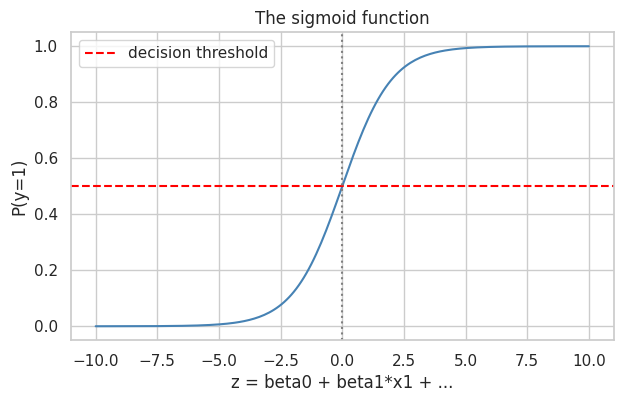

In [ ]:
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))
plt.plot(z, sigmoid, color='steelblue')
plt.axhline(0.5, color='red', linestyle='--', label='decision threshold')
plt.axvline(0, color='gray', linestyle=':')
plt.xlabel('z = beta0 + beta1*x1 + ...'); plt.ylabel('P(y=1)')
plt.title('The sigmoid function'); plt.legend()
plt.show()

Logistic regression test accuracy: 0.620


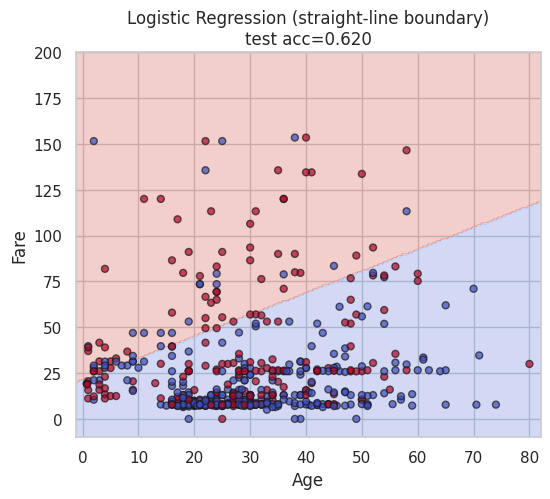

In [ ]:
logreg = LogisticRegression().fit(X2_train, y2_train)
acc_logreg = accuracy_score(y2_test, logreg.predict(X2_test))
print(f"Logistic regression test accuracy: {acc_logreg:.3f}")
plot_decision_boundary(logreg, X2_train, y2_train, f'Logistic Regression (straight-line boundary)\ntest acc={acc_logreg:.3f}')
plt.show()

---
# 3. K-Nearest Neighbors (KNN) — classification by similarity

KNN makes no assumption about the boundary's *shape* at all. To classify a new point, it looks at the **k closest training points** (by distance) and takes a majority vote. This directly uses the distance/scaling ideas from Week 5 Class 1 — KNN is very sensitive to feature scale, which is why we standardized our features in Setup.

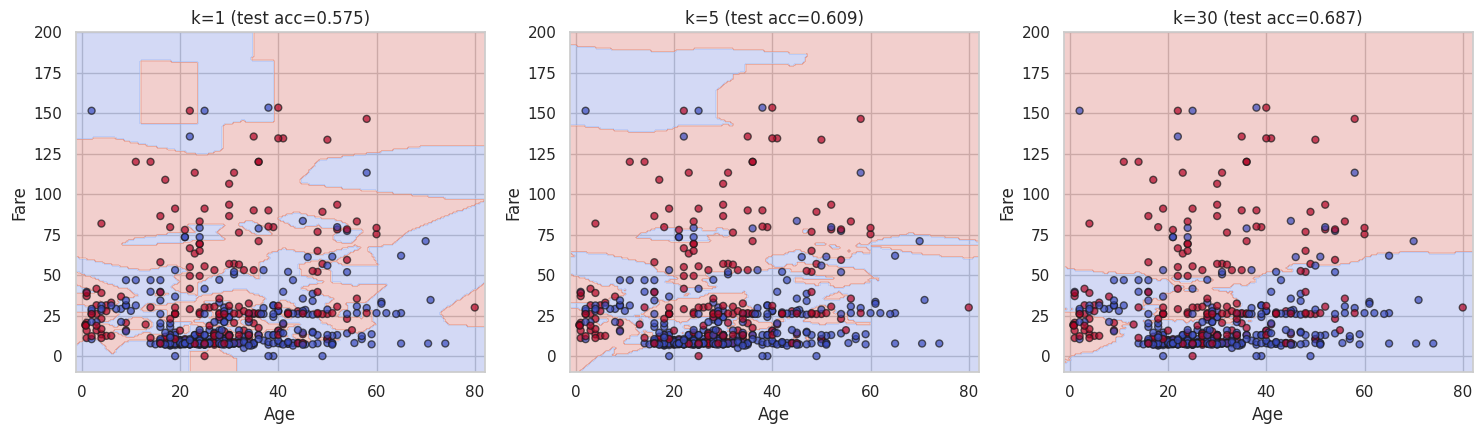

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, k in zip(axes, [1, 5, 30]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X2_train, y2_train)
    acc = accuracy_score(y2_test, knn.predict(X2_test))
    plot_decision_boundary(knn, X2_train, y2_train, f'k={k} (test acc={acc:.3f})', ax=ax)
plt.tight_layout()
plt.show()

Notice the pattern: small $k$ (e.g. $k=1$) creates a jagged, overly complex boundary that memorizes noise — **overfitting**. Large $k$ smooths the boundary but can miss real structure — **underfitting**. Choosing $k$ is a direct preview of next class's **bias-variance tradeoff**.

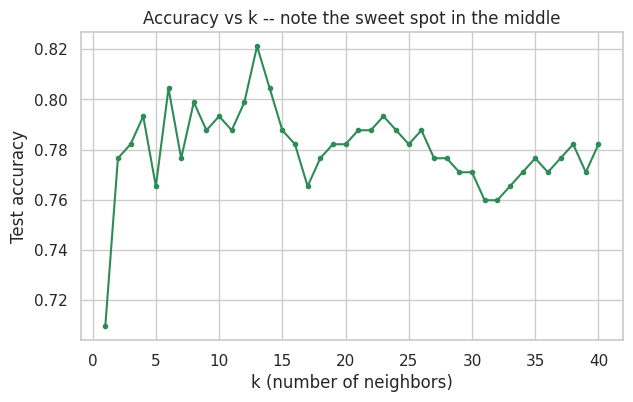

Best k: 13, accuracy: 0.821


In [ ]:
# Find the best k via a validation curve
ks = range(1, 41)
accs = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    accs.append(accuracy_score(y_test, knn.predict(X_test_s)))

plt.plot(ks, accs, marker='o', markersize=3, color='seagreen')
plt.xlabel('k (number of neighbors)'); plt.ylabel('Test accuracy')
plt.title('Accuracy vs k -- note the sweet spot in the middle')
plt.show()
print(f"Best k: {ks[np.argmax(accs)]}, accuracy: {max(accs):.3f}")

---
# 4. Decision Trees — classification via information gain

A decision tree asks a sequence of yes/no questions about features (e.g. "is `sex_code` < 0.5?"), splitting the data to make each resulting group as **pure** (single-class) as possible. The standard purity measure is **entropy**, borrowed straight from information theory:

$$H(S) = -\sum_i p_i \log_2 p_i$$

A pure group (all one class) has entropy 0; a 50/50 split has maximum entropy 1. Each split is chosen to maximize **information gain** — the entropy reduction from parent to children.

In [ ]:
def entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return -np.sum(probs * np.log2(probs))

print(f"Entropy of the full dataset (mixed classes): {entropy(y_train):.3f}")
print(f"Entropy of an all-died subset (pure):        {entropy(np.zeros(20)):.3f}")
print(f"Entropy of a 50/50 subset (max impurity):    {entropy(np.array([0]*10 + [1]*10)):.3f}")

Entropy of the full dataset (mixed classes): 0.974
Entropy of an all-died subset (pure):        -0.000
Entropy of a 50/50 subset (max impurity):    1.000


Decision tree (max_depth=3) test accuracy: 0.687


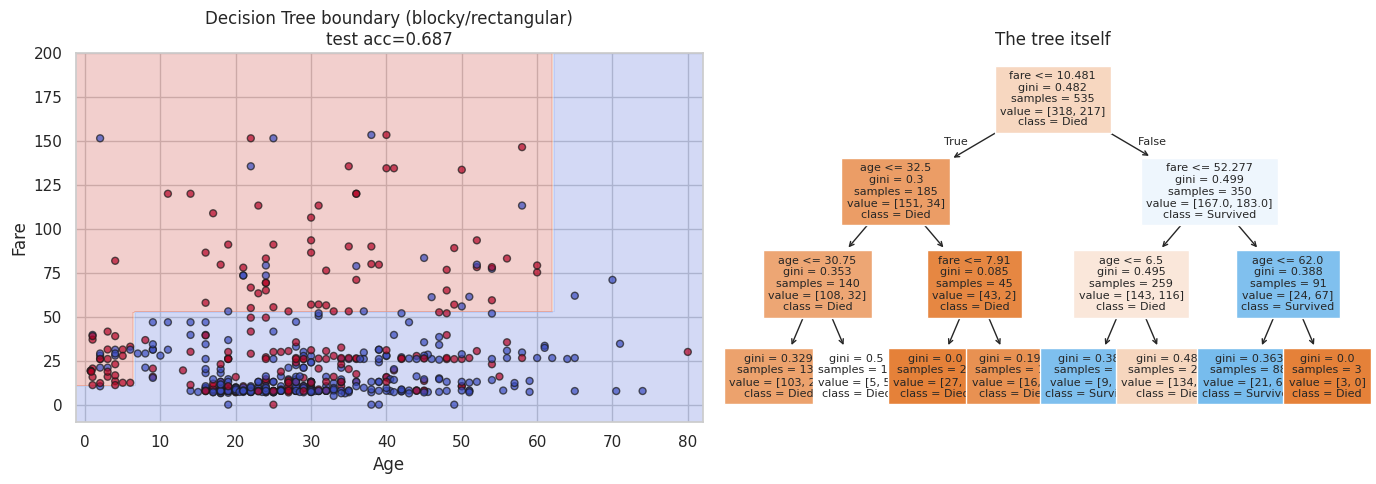

In [ ]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X2_train, y2_train)
acc_tree = accuracy_score(y2_test, tree.predict(X2_test))
print(f"Decision tree (max_depth=3) test accuracy: {acc_tree:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_decision_boundary(tree, X2_train, y2_train, f'Decision Tree boundary (blocky/rectangular)\ntest acc={acc_tree:.3f}', ax=axes[0])
plot_tree(tree, feature_names=['age','fare'], class_names=['Died','Survived'], filled=True, ax=axes[1], fontsize=8)
axes[1].set_title('The tree itself')
plt.tight_layout()
plt.show()

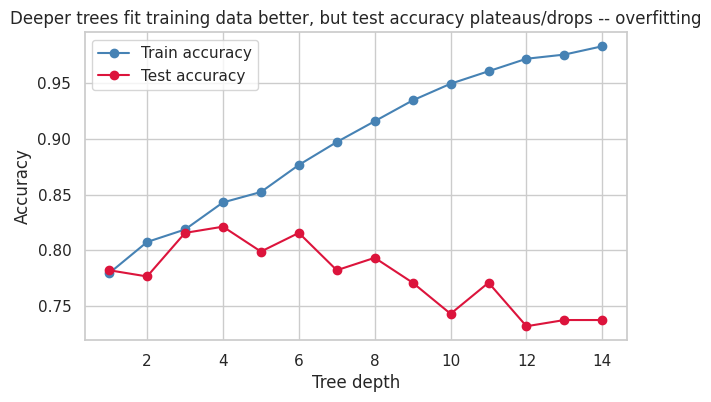

In [ ]:
# Tree depth is another overfitting knob, just like KNN's k
depths = range(1, 15)
train_accs, test_accs = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, t.predict(X_train)))
    test_accs.append(accuracy_score(y_test, t.predict(X_test)))

plt.plot(depths, train_accs, marker='o', label='Train accuracy', color='steelblue')
plt.plot(depths, test_accs, marker='o', label='Test accuracy', color='crimson')
plt.xlabel('Tree depth'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Deeper trees fit training data better, but test accuracy plateaus/drops -- overfitting')
plt.show()

---
# 5. Comparing all three

| Algorithm | Boundary shape | Key statistical idea | Sensitive to feature scale? |
|---|---|---|---|
| Logistic regression | Straight line / plane | Sigmoid-transformed linear combination | Somewhat (affects convergence) |
| KNN | Arbitrary, local | Distance / similarity | **Very** — must scale features |
| Decision Tree | Axis-aligned rectangles | Entropy / information gain | No — splits are scale-invariant |

                     Model  Test Accuracy
0      Logistic Regression       0.798883
1             KNN (best k)       0.821229
2  Decision Tree (depth=3)       0.815642


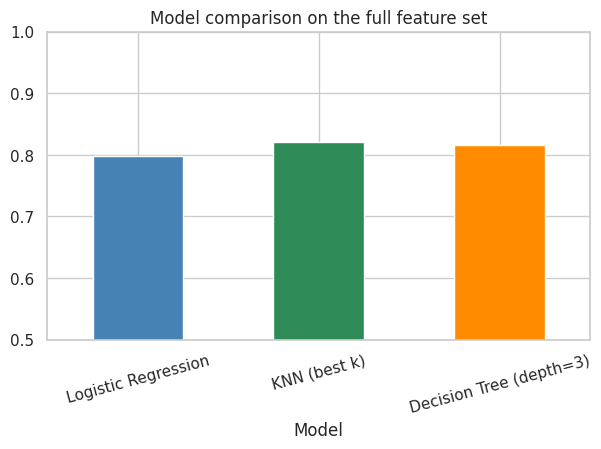

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN (best k)', 'Decision Tree (depth=3)'],
    'Test Accuracy': [
        accuracy_score(y_test, LogisticRegression(max_iter=1000).fit(X_train_s, y_train).predict(X_test_s)),
        max(accs),
        accuracy_score(y_test, DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train).predict(X_test)),
    ]
})
print(results)
results.plot(x='Model', y='Test Accuracy', kind='bar', legend=False, color=['steelblue','seagreen','darkorange'])
plt.ylim(0.5, 1.0); plt.xticks(rotation=15); plt.title('Model comparison on the full feature set')
plt.show()

No single algorithm always wins — it depends on whether the true boundary is roughly linear, locally clustered, or naturally rule-based. In practice, you try a few and let the held-out test performance (Week 5, Class 1's train/test discipline) decide.

---
# 6. Exercises

1. Retrain KNN using `['pclass', 'sex_code', 'age', 'fare']` (all 4 scaled features, not just 2) and re-run the k-sweep from Section 3. Does the optimal k change?
2. Plot the decision boundary for a decision tree with `max_depth=1` (a "decision stump"). What single question does it ask?
3. Compute entropy for the split "sex_code < 0.5" on the training data: entropy of the whole set, then the weighted average entropy of the two resulting groups. Is the information gain positive?
4. Try `DecisionTreeClassifier(max_depth=None)` (unlimited depth) and compare train vs. test accuracy. How extreme is the overfitting?
5. **Challenge**: Look up `weights='distance'` in `KNeighborsClassifier` (closer neighbors count more than farther ones). Does it improve test accuracy over the default uniform weighting?
